# Main notebook

### Init

In [20]:
# git add .
# git commit -m "message"
# git push origin main


%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import numpy as np
import torch
import deepchem as dc
import matplotlib.pyplot as plt

from src.data.dataMol import load_data, print_mol_types, featurize
from src.data.preprocess import keep_largest, salt_remover, preprocess, preprocess_conc
from src.utils.plotting import plot_smiles, plot_metals, plot_training


from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem import AllChem, Draw, PandasTools, Descriptors
from rdkit.Chem.rdmolops import GetAdjacencyMatrix
from rdkit.Chem.Draw import IPythonConsole

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Init Data

## Moldata

In [71]:
path = Path("Data") / "toxicity_fish.csv"
selected_columns = ["SMILES", "conc", "duration"]
cut = 10000
# cut = None

df = load_data(path, selected_columns, cut)

print(df.head())
print("")
print_mol_types(df)

       SMILES  conc  duration
0  O=[O+][O-]  0.18      96.0
1  O=[O+][O-]  0.18      96.0
2  O=[O+][O-]  0.26      48.0
3  O=[O+][O-]  0.26      48.0
4  O=[O+][O-]  0.17      96.0

Total molecules: 10000
Unique molecules: 2738
Salts: 3023, 30.23%
Single atoms: 62, 0.62%
Metals: 3098, 30.98%


### Data analysis

       SMILES  conc  duration
0  O=[O+][O-]  0.18      96.0
1  O=[O+][O-]  0.18      96.0
2  O=[O+][O-]  0.26      48.0
3  O=[O+][O-]  0.26      48.0
4  O=[O+][O-]  0.17      96.0


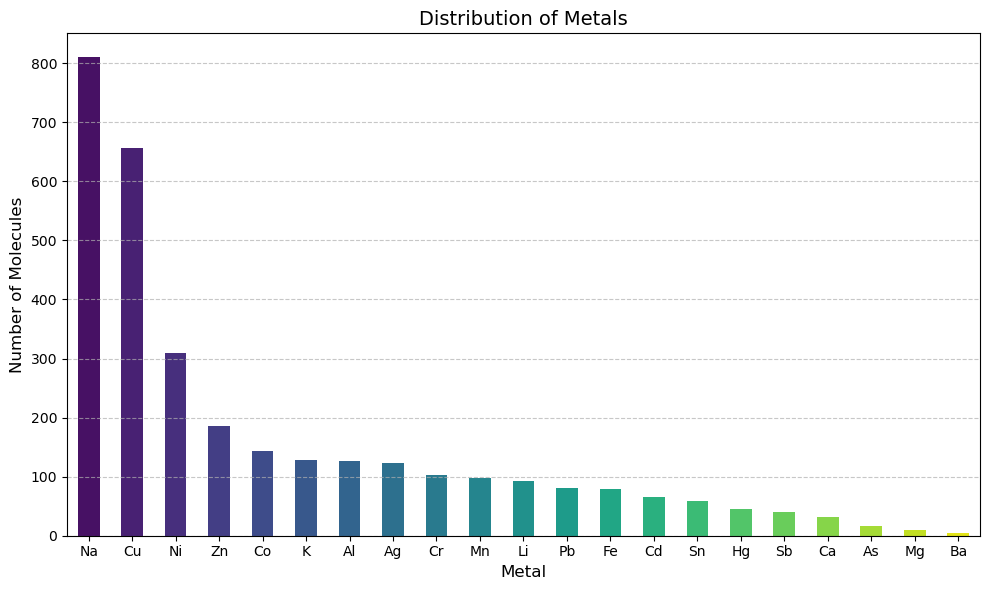

In [72]:
# Mol types and metals

mol_id = 16
print(df.head())

plot_metals(df)

### Data processing

In [73]:
# Preprocess by splitting salts, removing lone atoms and removing metals, also converting concentrations to log scale
df = preprocess(df, split_salts=False, remove_lone=False, remove_metals=False)

print(df.head())
print("")
print_mol_types(df)

       SMILES  conc  duration    log10c
0  O=[O+][O-]  0.18      96.0 -0.744727
1  O=[O+][O-]  0.18      96.0 -0.744727
2  O=[O+][O-]  0.26      48.0 -0.585027
3  O=[O+][O-]  0.26      48.0 -0.585027
4  O=[O+][O-]  0.17      96.0 -0.769551

Total molecules: 10000
Unique molecules: 2738
Salts: 3023, 30.23%
Single atoms: 62, 0.62%
Metals: 3098, 30.98%


### PyG

In [74]:
from torch_geometric.utils.smiles import from_smiles

# Featurize the data
df["features"] = df["SMILES"].apply(lambda x: from_smiles(x))

print(df["features"][0])
print("")
print(df.head())
print("")
print(f"Length of dataset: {len(df)}")

Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]')

       SMILES  conc  duration    log10c  \
0  O=[O+][O-]  0.18      96.0 -0.744727   
1  O=[O+][O-]  0.18      96.0 -0.744727   
2  O=[O+][O-]  0.26      48.0 -0.585027   
3  O=[O+][O-]  0.26      48.0 -0.585027   
4  O=[O+][O-]  0.17      96.0 -0.769551   

                                            features  
0  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
1  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
2  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
3  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  
4  [(x, [tensor([8, 0, 1, 5, 0, 0, 3, 0, 0]), ten...  

Length of dataset: 10000


In [75]:
print(from_smiles("[NH4+]").edge_index)
print(len(from_smiles("[NH4+]").edge_index[0]))
print(from_smiles("[NH4+]").edge_index.numel())

print(from_smiles("O=[O+][O-]").edge_index)
print(len(from_smiles("O=[O+][O-]").edge_index[0]))
print(from_smiles("O=[O+][O-]").edge_index.numel())


tensor([], size=(2, 0), dtype=torch.int64)
0
0
tensor([[0, 1, 1, 2],
        [1, 0, 2, 1]])
4
8


## Metadata

In [76]:
from src.data.dataMeta import encode_taxonomy

# all taxonomy features: "taxid", "superkingdom", "kingdom", "phylum", "subphylum", "class", "order", "family", "genus"
# selected taxonomy features for embedding, value is embedding_dim
embedding_size = {"taxid": 16, "genus": 8, "family": 8, "class": 4}
# embedding_size = {"genus": 8, "family": 8, "class": 4}

# Dataframe with taxonomy features only, for embedding
df_tax = load_data(path, embedding_size.keys(), cut)
print(df_tax.head())
print("")

# Encode taxonomy features to sequential integers for embedding layers
df_tax, encoders = encode_taxonomy(df_tax, embedding_size.keys())
print(df_tax.head())
print("")

# Create config: (number of unique values + 1 for unknown, embedding_dim)
config_tax = {
    col: (df_tax[col].nunique() + 1, dim) 
    for col, dim in embedding_size.items()
}
print("Category: num unique + 1, embedding dim")
print(config_tax)


      taxid     genus    family     class
0  238741.0  238740.0  461499.0  186623.0
1   28743.0   28741.0    8076.0  186623.0
2  238741.0  238740.0  461499.0  186623.0
3   28743.0   28741.0    8076.0  186623.0
4  238741.0  238740.0  461499.0  186623.0

   taxid  genus  family  class
0      1      1       1      1
1      2      2       2      1
2      1      1       1      1
3      2      2       2      1
4      1      1       1      1

Category: num unique + 1, embedding dim
{'taxid': (205, 16), 'genus': (144, 8), 'family': (69, 8), 'class': (3, 4)}


## Features

### from_smiles

In [77]:
from torch_geometric.utils.smiles import from_smiles

# Create list of graph objects with features and labels, also attach taxonomy indices as tensors directly on the graph object
features = []
for i in range(len(df)):
    g = df["features"][i]
    g.x = g.x.float()
    y = torch.tensor(df["log10c"][i], dtype=torch.float)
    g.y = y

    # Attach taxonomy indices as tensors directly on the graph object
    for col in embedding_size.keys():
        setattr(g, col, torch.tensor(df_tax[col][i], dtype=torch.long))

    g.duration = torch.tensor(df["duration"][i], dtype=torch.float)
    
    features.append(g)

print(type(features[0]))
print(features[0])
print(len(features))

<class 'torch_geometric.data.data.Data'>
Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]', y=-0.7447274923324585, taxid=1, genus=1, family=1, class=1, duration=96.0)
10000


In [78]:
mol_id = 16

print(type(features[mol_id]))

print(features[mol_id])
print("")
# node_features: n_atoms x n_node_features
# - atomic_num, chirality, degree, formal_charge, num_hs, num_radical_r, hybridization, is_aromatic, is_in_ring
print("Node features for one atom example:")
print(features[mol_id].x[0])
# edge_index: 2 x n_edges (source and target) - shows bonds
# edge_features: n_edges x n_edge_features
# -  bond_type, stereo, is_conjugated
print("Edge features for one bond example:")
print(features[mol_id].edge_attr[0])

<class 'torch_geometric.data.data.Data'>
Data(x=[9, 9], edge_index=[2, 18], edge_attr=[18, 3], smiles='Nc1ccc(Cl)c(Cl)c1', y=1.1238516569137573, taxid=3, genus=3, family=3, class=1, duration=96.0)

Node features for one atom example:
tensor([7., 0., 3., 5., 2., 0., 3., 0., 0.])
Edge features for one bond example:
tensor([1, 0, 1])


# Dataset and DataLoader

In [79]:
from torch.utils.data import random_split
from src.utils.splitter import scaffold_split, scaffold_split_ac, butina_split


# Create a dataset
frac_train = 0.8
train_size = int(frac_train * len(features))
test_size = len(features) - train_size

# train_dataset, test_dataset = random_split(features, [train_size, test_size])
# train_dataset, test_dataset, val_dataset = scaffold_split(features, frac_train=0.8, frac_test=0.2, frac_valid=0.0)
# train_dataset, test_dataset, val_dataset = scaffold_split_ac(features, frac_train=0.8, frac_test=0.2, frac_valid=0.0)
train_dataset, test_dataset = butina_split(features, frac_train=0.8, frac_test=0.2)


print(type(train_dataset))
print(f"Train set size: {len(train_dataset)} - {len(train_dataset) / len(features) * 100:.2f}%")
print(f"Test set size: {len(test_dataset)} - {len(test_dataset) / len(features) * 100:.2f}%")


<class 'list'>
Train set size: 7998 - 79.98%
Test set size: 2002 - 20.02%


In [80]:
train_mol = [g.smiles for g in train_dataset]
test_mol  = [g.smiles for g in test_dataset]
print(f"Unique molecules in train: {len(set(train_mol))}")
print(f"Unique molecules in test:  {len(set(test_mol))}")
print(f"Test molecules not in train: {len(set(test_mol) - set(train_mol))}")

# print("")
# train_taxid = [g.taxid.item() for g in train_dataset]
# test_taxid  = [g.taxid.item() for g in test_dataset]
# print(f"Unique taxid in train: {len(set(train_taxid))}")
# print(f"Unique taxid in test:  {len(set(test_taxid))}")
# print(f"Test taxid not in train: {len(set(test_taxid) - set(train_taxid))}")

print("")
print("Mean concentration in train: ", np.mean([g.y.item() for g in train_dataset]).round(4))
print("Std of concentration in train: ", np.std([g.y.item() for g in train_dataset]).round(4))
print("Mean concentration in test:  ", np.mean([g.y.item() for g in test_dataset]).round(4))
print("Std of concentration in test: ", np.std([g.y.item() for g in test_dataset]).round(4))

Unique molecules in train: 1666
Unique molecules in test:  1505
Test molecules not in train: 1072

Mean concentration in train:  0.8495
Std of concentration in train:  1.3807
Mean concentration in test:   1.1028
Std of concentration in test:  1.3332


#### Normalize conc

In [81]:
# Normalization of targets using train set statistics, applied to both train and test sets
target_mean = np.mean([g.y.item() for g in train_dataset])
target_std = np.std([g.y.item() for g in train_dataset])

for g in train_dataset:
    g.y = (g.y - target_mean) / target_std

for g in test_dataset:
    g.y = (g.y - target_mean) / target_std

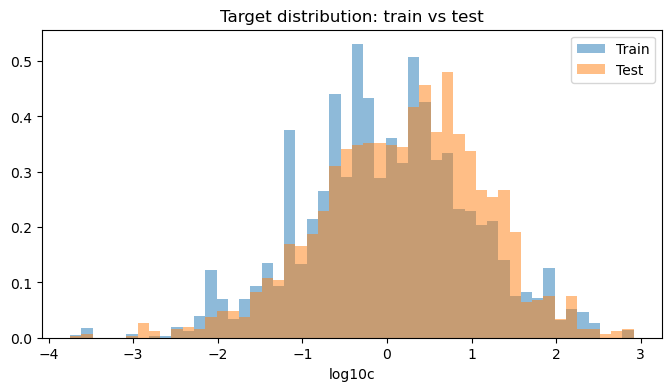

Train mean: -0.00, std: 1.00
Test mean:  0.18,  std: 0.97


In [82]:
from src.utils.plotting import plot_toxicity_distribution

plot_toxicity_distribution(train_dataset, test_dataset)

In [83]:
from torch_geometric.loader import DataLoader
# DataLoader
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


print(type(train_loader))

<class 'torch_geometric.loader.dataloader.DataLoader'>


# GNN

In [87]:
import torch
from src.model.modelMeta import TaxonomyEncoder, MetaEncoder
from src.model.modelGCN import GCN
from src.model.modelAFP import AttentiveFP
from src.model.modelGIN import GIN
from src.model.modelFull import ToxicityModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

gnn_out=64
gnn_hidden=32
meta_out=16


# model_tax = TaxonomyEncoder(config_tax).to(device)

meta_encoder = MetaEncoder(config_tax, hidden_dim=meta_out).to(device)

# model_gnn = GCN(
#     mol_dim=9,
#     hidden_dim=64,
#     output_dim=64
# ).to(device)

model_gnn = AttentiveFP(
    in_channels=9,
    edge_dim=3,
    hidden_channels=64,
    out_channels=gnn_out,
    num_layers=2,
    num_timesteps=2,
    dropout=0.4
).to(device)

# model_gnn = GIN(
#     mol_dim=9,
#     hidden_dim=gnn_hidden,
#     output_dim=gnn_out
# ).to(device)


model_full = ToxicityModel(model_gnn, meta_encoder, gnn_dim=gnn_out, encoder_dim=gnn_out + meta_out, hidden_dim=64).to(device)


Device: cpu


In [27]:
print(features[0])

Data(x=[3, 9], edge_index=[2, 4], edge_attr=[4, 3], smiles='O=[O+][O-]', y=-0.7447274923324585, taxid=1, genus=1, family=1, class=1, duration=96.0)


### Training

Epoch 0: Train Loss = 0.6025, Test Loss = 0.5725
Epoch 10: Train Loss = 0.4378, Test Loss = 0.5001
Epoch 20: Train Loss = 0.3921, Test Loss = 0.4798
Epoch 30: Train Loss = 0.3511, Test Loss = 0.4762
Epoch 40: Train Loss = 0.3216, Test Loss = 0.4508
Epoch 50: Train Loss = 0.2968, Test Loss = 0.4425
Epoch 60: Train Loss = 0.2759, Test Loss = 0.4355
Epoch 70: Train Loss = 0.2625, Test Loss = 0.4315
Epoch 80: Train Loss = 0.2481, Test Loss = 0.4316
Epoch 90: Train Loss = 0.2381, Test Loss = 0.4250
Epoch 100: Train Loss = 0.2314, Test Loss = 0.4219
Epoch 110: Train Loss = 0.2194, Test Loss = 0.4163
Epoch 120: Train Loss = 0.2130, Test Loss = 0.4186
Epoch 130: Train Loss = 0.2054, Test Loss = 0.4103
Epoch 140: Train Loss = 0.2029, Test Loss = 0.4109
Epoch 150: Train Loss = 0.1901, Test Loss = 0.4011
Epoch 160: Train Loss = 0.1864, Test Loss = 0.4076
Epoch 170: Train Loss = 0.1790, Test Loss = 0.4086
Epoch 180: Train Loss = 0.1805, Test Loss = 0.4076
Epoch 190: Train Loss = 0.1755, Test Loss 

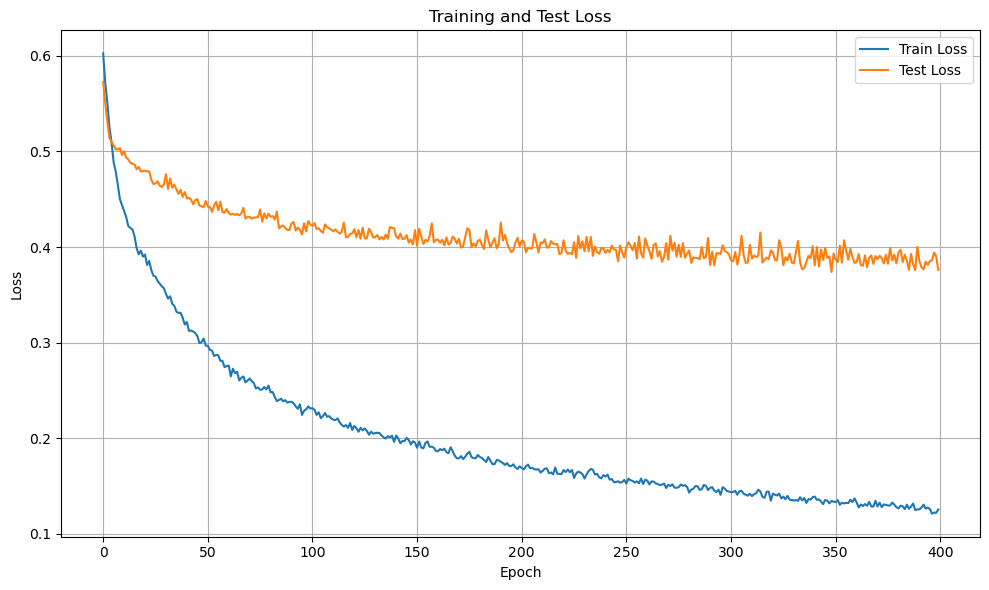

In [88]:
from src.model.eval import train
from src.utils.plotting import plot_training

model = model_full

# loss_fn = torch.nn.MSELoss()
# loss_fn = torch.nn.L1Loss()
loss_fn = torch.nn.SmoothL1Loss(beta=0.5)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

# ReduceLROnPlateau halves the learning rate if validation loss doesn't improve for X epochs
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=15, factor=0.5, min_lr=1e-6)
# CosineAnnealingLR reduces the learning rate following a cosine curve, with restarts every T_max epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=400, eta_min=1e-6
)

model_trained, history = train(model, train_loader, test_loader, loss_fn=loss_fn, optimizer=optimizer, scheduler=scheduler, epochs=400, device=device)

plot_training(history)


In [96]:
from sklearn.metrics import r2_score

preds, targets = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch)
        preds.extend(pred.squeeze().cpu().numpy())
        targets.extend(batch.y.cpu().numpy())

print(f"R²: {r2_score(targets, preds):.3f}")  # want this well above 0
# print(f"RMSE: {np.sqrt(mean_squared_error(targets, preds)):.3f}")

R²: 0.158


In [97]:
from sklearn.metrics import r2_score
from src.utils.splitter import generate_scaffold

model.eval()
preds, targets, scaffolds = [], [], []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch).squeeze()
        preds.extend(pred.cpu().numpy())
        targets.extend(batch.y.cpu().numpy())
        scaffolds.extend(batch.smiles)

# Get scaffold for each test molecule
scaffold_list = [generate_scaffold(smi) for smi in scaffolds]

results_df = pd.DataFrame({
    "pred": preds,
    "actual": targets,
    "scaffold": scaffold_list
})

print(results_df.groupby("scaffold").apply(
    lambda g: pd.Series({
        "n": len(g),
        "r2": r2_score(g["actual"], g["pred"]) if len(g) > 1 else np.nan,
        "mean_error": (g["pred"] - g["actual"]).abs().mean()
    })
).sort_values("r2"))

                                           n            r2  mean_error
scaffold                                                              
f308bbfa1fbd1ae60aca34d24f52d0d8        12.0 -1.410246e+16    0.884785
2d2be46464b4b751a104ad98676e5e20        10.0 -9.926439e+15    0.742313
8a264fc87304db99a57ccfefeb9e6879        10.0 -8.403209e+15    1.365975
O=C(OCc1ccccc1)C1Cc2ccccc2CN1.c1ccccc1   5.0 -7.672887e+15    0.652634
777fdca8e3a438ef1e01c2bdd1f61aae        12.0 -5.291939e+15    1.083996
...                                      ...           ...         ...
fe39190d547aad9b1e5fdc6d94471a6c         1.0           NaN    0.297306
fe968c3bbf55cd6f81de1b10663360b2         1.0           NaN    0.538350
ff652dc3b74c5badd310c538f0cd257d         1.0           NaN    1.150127
ff91d8cdc7b613210ba5c876455a08c6         1.0           NaN    0.560010
n1n[n-]c(-c2nnn[n-]2)n1                  1.0           NaN    2.099717

[1508 rows x 3 columns]


/tmp/ipykernel_2587898/3346415317.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(results_df.groupby("scaffold").apply(


Text(0, 0.5, 'Predicted log10c')

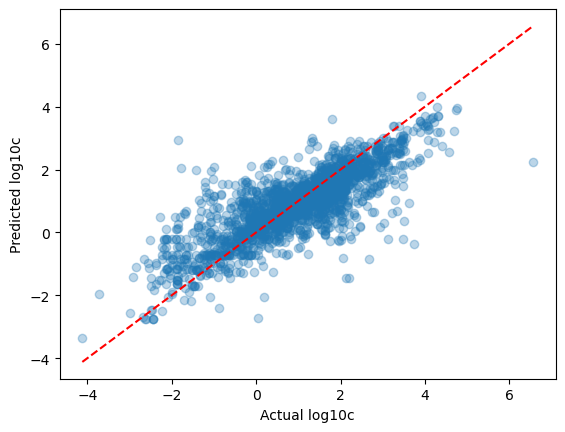

In [29]:
import matplotlib.pyplot as plt
plt.scatter(targets, preds, alpha=0.3)
plt.plot([min(targets), max(targets)], [min(targets), max(targets)], 'r--')
plt.xlabel("Actual log10c")
plt.ylabel("Predicted log10c")